## **Classwork: "The Memory Machine" — Basics of Recurrent Neural Networks**

**The Scenario**

You have just joined "SeqSense AI", a startup building a next-word prediction engine for a regional language keyboard. The founding engineer hands you a codebase that uses a plain MLP — it predicts the next word by looking only at the *current* word, with no memory of what came before. Naturally, it is terrible. Your task is to understand how Recurrent Neural Networks (RNNs) solve this problem by threading a hidden state through time, implement the RNN forward pass from scratch, and observe the vanishing gradient problem that motivates LSTMs and GRUs.

## **Part 1:**

### **Question 1: Why Not Just Use an MLP on the Whole Sequence?**

Your colleague suggests: "Just concatenate all the words in the sentence into one big vector and feed it to an MLP." What is the fundamental problem with this approach for sequence modelling?

A) MLPs cannot use tanh activations, which are required for language data.

B) The input size of an MLP is fixed at training time, so it cannot handle sequences of variable length, and it treats all positions identically with no notion of order.

C) MLPs are too slow to process more than one word at a time.

D) Concatenating word vectors always causes the vanishing gradient problem.

Answer: (B), The input size of an MLP is fixed at training time, so it cannot handle sequences of variable length, and it treats all positions identically with no notion of order.

### **Question 2: The Hidden State**

In a vanilla RNN, the hidden state $h_t$ is updated at each time step $t$ using the recurrence:
$$h_t = \tanh(W_{hh}\, h_{t-1} + W_{xh}\, x_t + b_h)$$

What is the role of $h_{t-1}$ in this equation?

A) It is a forget gate that decides which parts of the input $x_t$ to ignore.

B) It carries a compressed summary of all previous inputs $x_1, x_2, \ldots, x_{t-1}$ into the current time step, giving the network a form of memory.

C) It normalises the input $x_t$ to prevent exploding activations.

D) It is the gradient of the loss with respect to the current input.

Answer: (B), It carries a compressed summary of all previous inputs $x_1, x_2, \ldots, x_{t-1}$ into the current time step, giving the network a form of memory.
$h_{t-1}$ carries forward a compressed summary of previous inputs $(x_1,\dots,x_{t-1})$, giving the RNN memory of past context when computing $h_t$.


### **Question 3: The Vanishing Gradient Problem**

During Backpropagation Through Time (BPTT), gradients are propagated backwards across all time steps. For a sequence of length $T$, the gradient of the loss with respect to an early hidden state $h_1$ involves repeated multiplication by the weight matrix $W_{hh}$. What goes wrong when $T$ is large?

A) The gradient explodes to infinity in all cases, making training impossible.

B) If the dominant eigenvalue of $W_{hh}$ is less than 1, the gradient shrinks exponentially as it travels back through time steps, effectively preventing the network from learning long-range dependencies.

C) The hidden state $h_t$ grows too large to fit in memory.

D) The tanh activation forces all gradients to exactly zero after $T > 10$ steps.

Answer: (B), If the dominant eigenvalue of $W_{hh}$ is less than 1, the gradient shrinks exponentially as it travels back through time steps, effectively preventing the network from learning long-range dependencies.


## **Part 2:**

### **Question 4: Manual Forward Pass**

You have a tiny RNN with the following parameters (all scalars for simplicity):

| Parameter | Value |
|---|---|
| $W_{xh}$ | 0.5 |
| $W_{hh}$ | 0.8 |
| $b_h$ | 0.0 |
| $W_{hy}$ | 1.0 |
| $b_y$ | 0.0 |
| $h_0$ | 0.0 |

The update rules are:
$$h_t = \tanh(W_{hh}\, h_{t-1} + W_{xh}\, x_t + b_h)$$
$$\hat{y}_t = W_{hy}\, h_t + b_y$$

The input sequence is $x_1 = 1.0,\ x_2 = 0.0,\ x_3 = 1.0$.

Compute $h_1$, $h_2$, $h_3$, and $\hat{y}_3$ step by step. Use $\tanh(0.5) \approx 0.462$, $\tanh(0.370) \approx 0.354$, $\tanh(0.783) \approx 0.654$.

Using  
$$
h_t=\tanh(W_{hh}h_{t-1}+W_{xh}x_t+b_h),\quad \hat y_t=W_{hy}h_t+b_y
$$
with $W_{xh}=0.5,\;W_{hh}=0.8,\;b_h=0,\;W_{hy}=1,\;b_y=0,\;h_0=0$, and
$(x_1,x_2,x_3)=(1,0,1)$:

- $h_1$:
    $$
    h_1=\tanh(0.8\cdot 0 + 0.5\cdot 1 + 0)=\tanh(0.5)\approx 0.462
    $$

- $h_2$:
    $$
    h_2=\tanh(0.8\cdot h_1 + 0.5\cdot 0 + 0)=\tanh(0.8\cdot 0.462)=\tanh(0.370)\approx 0.354
    $$

- $h_3$:
    $$
    h_3=\tanh(0.8\cdot h_2 + 0.5\cdot 1 + 0)=\tanh(0.8\cdot 0.354+0.5)=\tanh(0.783)\approx 0.654
    $$

- $\hat y_3$:
    $$
    \hat y_3=1.0\cdot h_3+0 = h_3 \approx 0.654
    $$

So the computed values are:
$$
h_1\approx 0.462,\quad h_2\approx 0.354,\quad h_3\approx 0.654,\quad \hat y_3\approx 0.654.
$$


## **Part 3: Coding Challenge — Building an RNN from Scratch**

You will implement the vanilla RNN forward pass in NumPy, run it on a toy sequence, and then visualise how the hidden state evolves over time and how gradients shrink during BPTT.

**Fill in the lines marked `## FILL IN`.**

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Hyperparameters ---
input_size  = 4   # dimensionality of each input vector x_t
hidden_size = 6   # dimensionality of hidden state h_t
output_size = 2   # dimensionality of output y_t
seq_len     = 10  # number of time steps T

# --- Random weight initialisation (small values) ---
W_xh = np.random.randn(hidden_size, input_size)  * 0.1  # input  -> hidden
W_hh = np.random.randn(hidden_size, hidden_size) * 0.1  # hidden -> hidden
W_hy = np.random.randn(output_size, hidden_size) * 0.1  # hidden -> output
b_h  = np.zeros(hidden_size)
b_y  = np.zeros(output_size)

# --- Toy input sequence: T steps of random input_size-dim vectors ---
X = np.random.randn(seq_len, input_size)

print("Weight shapes:")
print(f"  W_xh: {W_xh.shape}")
print(f"  W_hh: {W_hh.shape}")
print(f"  W_hy: {W_hy.shape}")
print(f"  Input sequence X: {X.shape}")

Weight shapes:
  W_xh: (6, 4)
  W_hh: (6, 6)
  W_hy: (2, 6)
  Input sequence X: (10, 4)


In [7]:
# ---------------------------------------------------------------
# Task A: Implement the RNN forward pass
# ---------------------------------------------------------------

def rnn_forward(X, W_xh, W_hh, W_hy, b_h, b_y):
    """
    Run the RNN forward pass over the full input sequence X.

    Args:
        X      : (T, input_size)  — input sequence
        W_xh   : (hidden_size, input_size)
        W_hh   : (hidden_size, hidden_size)
        W_hy   : (output_size, hidden_size)
        b_h    : (hidden_size,)
        b_y    : (output_size,)

    Returns:
        h_states : (T, hidden_size) — hidden state at every time step
        y_hat    : (T, output_size) — output at every time step
    """
    T = X.shape[0]
    hidden_size = W_hh.shape[0]
    output_size = W_hy.shape[0]

    h_states = np.zeros((T, hidden_size))
    y_hat    = np.zeros((T, output_size))

    # Initial hidden state
    h_prev = np.zeros(hidden_size)

    for t in range(T):
        x_t = X[t]

        ## FILL IN: compute the new hidden state h_t
        ## Formula: h_t = tanh(W_hh @ h_prev + W_xh @ x_t + b_h)
        ## Hint: use np.tanh()
        tanh_input = W_hh @ h_prev + W_xh @ x_t + b_h
        h_t = np.tanh(tanh_input)

        ## FILL IN: compute the output y_hat_t
        ## Formula: y_hat_t = W_hy @ h_t + b_y
        y_hat_t = W_hy @ h_t + b_y

        h_states[t] = h_t
        y_hat[t]    = y_hat_t
        h_prev      = h_t

    return h_states, y_hat


h_states, y_hat = rnn_forward(X, W_xh, W_hh, W_hy, b_h, b_y)

print(f"Hidden states shape : {h_states.shape}")
print(f"Output shape        : {y_hat.shape}")
print(f"\nFirst 3 hidden states (h_1 to h_3):")
print(h_states[:3].round(4))

Hidden states shape : (10, 6)
Output shape        : (10, 2)

First 3 hidden states (h_1 to h_3):
[[-0.0678 -0.3683  0.1681  0.1051  0.1728 -0.1736]
 [-0.2999 -0.1714  0.1276  0.108   0.2875  0.2293]
 [-0.0192  0.1594  0.023  -0.2972 -0.0131  0.0145]]


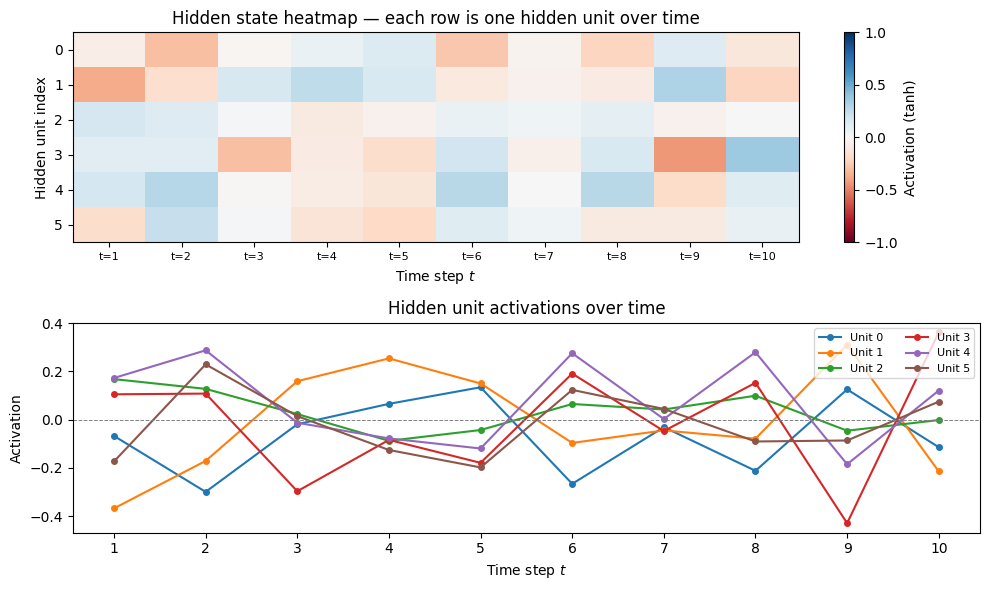

In [8]:
# ---------------------------------------------------------------
# Task B: Visualise how each hidden unit evolves over time
# ---------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Plot 1: heatmap of h_states (time steps x hidden units)
im = axes[0].imshow(h_states.T, aspect='auto', cmap='RdBu',
                    vmin=-1, vmax=1, interpolation='nearest')
axes[0].set_xlabel('Time step $t$')
axes[0].set_ylabel('Hidden unit index')
axes[0].set_title('Hidden state heatmap — each row is one hidden unit over time')
axes[0].set_xticks(range(seq_len))
axes[0].set_xticklabels([f't={i+1}' for i in range(seq_len)], fontsize=8)
plt.colorbar(im, ax=axes[0], label='Activation (tanh)')

# Plot 2: line plot of selected hidden units
for unit in range(hidden_size):
    axes[1].plot(range(1, seq_len + 1), h_states[:, unit],
                 marker='o', markersize=4, label=f'Unit {unit}')

axes[1].set_xlabel('Time step $t$')
axes[1].set_ylabel('Activation')
axes[1].set_title('Hidden unit activations over time')
axes[1].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[1].legend(fontsize=8, loc='upper right', ncol=2)
axes[1].set_xticks(range(1, seq_len + 1))

plt.tight_layout()
plt.show()

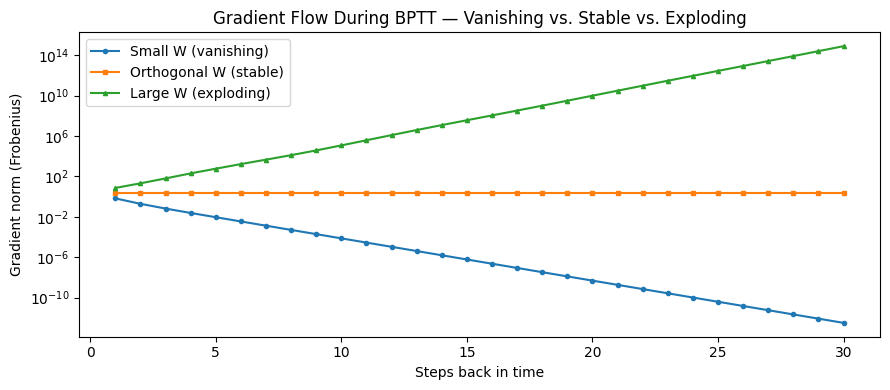

In [10]:
# ---------------------------------------------------------------
# Task C: Visualise the vanishing gradient problem
#
# During BPTT, the gradient of the loss at time T with respect
# to h_t involves multiplying by W_hh^T once per step backwards.
# We simulate this by tracking the Frobenius norm of the
# gradient matrix as it is propagated back through time.
# ---------------------------------------------------------------

def simulate_gradient_flow(W_hh, seq_len):
    """
    Simulates how a gradient matrix shrinks (or explodes)
    as it is backpropagated through `seq_len` time steps.

    At each step backwards we multiply by W_hh.T — identical
    to what BPTT does, ignoring the tanh derivative for clarity.

    Returns a list of gradient norms, one per time step (T down to 1).
    """
    grad = np.eye(W_hh.shape[0])  # start with identity
    norms = []

    for _ in range(seq_len):
        ## FILL IN: multiply grad by W_hh.T (backprop one step)
        ## then compute and append the Frobenius norm of grad
        ## Hint: np.linalg.norm()
        grad = np.linalg.matrix_power(W_hh.T, _ + 1)  # equivalent to multiplying by W_hh.T repeatedly
        norms.append(np.linalg.norm(grad))

    return norms


# --- Compare three regimes ---
T_long = 30

# Small weights  → vanishing
W_small  = np.random.randn(hidden_size, hidden_size) * 0.1

# Orthogonal matrix → stable (eigenvalues all magnitude 1)
W_ortho, _ = np.linalg.qr(np.random.randn(hidden_size, hidden_size))

# Large weights → exploding
W_large  = np.random.randn(hidden_size, hidden_size) * 1.5

norms_small  = simulate_gradient_flow(W_small,  T_long)
norms_ortho  = simulate_gradient_flow(W_ortho,  T_long)
norms_large  = simulate_gradient_flow(W_large,  T_long)

plt.figure(figsize=(9, 4))
plt.plot(range(1, T_long + 1), norms_small,  label='Small W (vanishing)',  marker='o', markersize=3)
plt.plot(range(1, T_long + 1), norms_ortho,  label='Orthogonal W (stable)', marker='s', markersize=3)
plt.plot(range(1, T_long + 1), norms_large,  label='Large W (exploding)',  marker='^', markersize=3)
plt.xlabel('Steps back in time')
plt.ylabel('Gradient norm (Frobenius)')
plt.title('Gradient Flow During BPTT — Vanishing vs. Stable vs. Exploding')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

Write your observations:

> **Task A/B:**
> 1. Look at the hidden state heatmap. Do the hidden units all behave the same way, or do different units seem to track different patterns over time? What does this suggest about what the hidden state is encoding?
> 2. The hidden state at $t=10$ was influenced by the input at $t=1$. After seeing the line plots, do you think a vanilla RNN with small random weights reliably remembers information from many steps ago? Why or why not?
>
> **Task C:**
> 3. Describe what you see in the gradient norm plot for the three weight regimes. How does each one behave as you go further back in time?
> 4. Based on the vanishing gradient plot, why would a vanilla RNN struggle to learn that the word "not" at position $t=1$ reverses the sentiment of a sentence that ends at $t=20$?

...


> **Task A/B:**
> 1. The hidden units do **not** behave the same way. From the heatmap/line plot, some units stay mostly small, some flip sign, and some show sharper peaks at specific time steps. This suggests the hidden state is distributed: different dimensions encode different temporal features/patterns of the sequence.
>
> 2. A vanilla RNN with small random recurrent weights does **not** reliably remember information from far back in time. In this run, activations are modest and keep changing with recent inputs, so earlier information is gradually overwritten. This is consistent with weak long-term memory in plain RNNs.
>
> **Task C:**
> 3. The three regimes show classic behavior:
>    - **Small $W$**: gradient norms decay exponentially (about $0.67 \to 3.05\times10^{-13}$ by 30 steps) → strong vanishing gradients.
>    - **Orthogonal $W$**: norms stay nearly constant ($\approx 2.449$) across all steps → stable gradient flow.
>    - **Large $W$**: norms blow up rapidly ($\sim 7.16 \to 8.01\times10^{14}$) → exploding gradients.
>
> 4. For a dependency like “**not**” at $t=1$ affecting sentiment at $t=20$, learning requires error signals to travel far back. In the vanishing regime, those gradients become almost zero long before reaching early steps, so the model cannot effectively adjust parameters to preserve that long-range dependency.